In [ ]:
from pysat.formula import CNF
from pysat.solvers import Solver
from pysat.solvers import Kissat404
from pysat.solvers import Glucose42
from pysat.solvers import Cadical300
from partitionsolver.utils import file_reader
from multiprocessing import Process, Queue
import partitionsolver.utils.hypergraph_worker as hypergraph_worker
import time
import os
import json
import multiprocessing as mp

import builtins
import functools
import numpy as np

from partitionsolver.partitioning.hypergraph_edges import HyperGraphEdges

from partitionsolver.solver.partition_solver_dpll import PartitionDPLL
from partitionsolver.solver.partition_solver_cdcl import PartitionCDCL
from partitionsolver.solver.partition_propagator import PartitionPropagator
from partitionsolver.utils import literal_util

import lzma


In [ ]:
builtins.print = functools.partial(print, flush=True)


timings_file = "../output/timings.json"
timings_file_old = "../output/timings_old.json"

#cnf_file_location = "./instances/instances_small/d6afa5689d75e37111656db8980dd54b-grs-160-48.cnf.xz"
#cnf_file_location = "./instances/instances_small/4c3001f8073986116d98084dde70da05-fsf-300-354-2-2-3-2.9.opt.cnf.xz"
#cnf_file_location = "./instances/instances_small/ad9eb96bac59319fc2f7daffd1f961f8-AProVE07-21.cnf.xz"
#cnf_file_location = "./instances/instances_small/77a0d54f2fb3740a9a321623c0c10f3e-tseitin_grid_n12_m12.cnf.xz"
#cnf_file_location = "./instances/instances_small/b628043a07c5576dd6cd21c9d73a69e0-fixedbandwidth-eq-37_shuffled.cnf.xz"
#cnf_file_location = "./instances/custom/two_random_connect8.cnf"
cnf_file_location = "../instances/random_sat/uf50-028.cnf"

In [ ]:

stats = {}

def load_stats_file():
    global stats
    if stats is None:
        try:
            with open(timings_file) as f:
                stats = json.load(f)
        except FileNotFoundError:
            stats = {}
    return stats

def save_stats():
    global stats
    if stats is None:
        return
    
    old_stats = {}
    try:
        with open(timings_file_old) as f:
            old_stats = json.load(f)
    except FileNotFoundError:
        old_stats = {}

    with open(timings_file_old, "w") as f:
        json.dump(old_stats, f, indent=2)
    with open(timings_file, "w") as f:
        json.dump(stats, f, indent=2)

def set_stat(path, solver, satisfiable, time, variables, clauses, extradata = None):
    if path not in stats:
        stats[path] = {
            "variables": variables,
            "clauses": clauses
        }
    stats[path][solver] = {
        "satisfiable": satisfiable,
        "time": time,
        "data": extradata
    }

In [ ]:
import os
import time
from time import sleep

import matplotlib.pyplot as plt

results = {}

def solve_and_compare(file_location: str, display_progress: bool = False):
    # === Read the clauses from file ===
    num_vars, num_clauses, clauses = file_reader.read_cnf(file_location)
    print(f"Details: vars {num_vars}, clauses {num_clauses}")

    instance_name = os.path.basename(file_location)
    results[instance_name] = {}

    # === Normal Sat Solver ===
    clauses_all = [clause.tolist() for clause in clauses]

    cnf_whole = CNF(from_clauses=clauses_all)
    start = time.perf_counter()
    with Cadical300(bootstrap_with=cnf_whole) as solver:
        sat1 = solver.solve()
        cadical_time_ms = 1000 * (time.perf_counter() - start)
        print(f"Cadical300: {sat1}. Solved in {cadical_time_ms:.2f}ms")
        results[instance_name]["Cadical300"] = cadical_time_ms


    # === Solve the partial formulas independently ===
    split = HyperGraphEdges(file_location=file_location, splits_amount=2)
    formulas, comm_variables = split.split_formula(clauses_all, num_vars, num_clauses)
    start = time.perf_counter()

    prop_solver = PartitionPropagator(num_vars, comm_variables, formulas, debug_level=0)
    prop_sat = prop_solver.solve()
    custom_time_ms = 1000 * (time.perf_counter() - start)

    if prop_solver.add_seed_clauses:
        print(f"Split Sat({len(comm_variables)} / {num_vars} split): {prop_sat}, "
              f"solved in {custom_time_ms:.2f}ms ({1000 * (prop_solver.seed_clauses_time):.2f} warmup)")
    else:
        print(f"Split Sat({len(comm_variables)} / {num_vars} split): {prop_sat}, solved in {custom_time_ms:.2f}ms)")

    results[instance_name]["CustomSolver"] = custom_time_ms

    assert prop_sat == sat1


for _ in range(0):
    solve_and_compare("../instances/test/unsat_problem/bf1355-638.cnf", True)

max_entries = 10
for entry in os.scandir("../instances/random_sat"):
    max_entries -= 1
    if max_entries < 0:
        break
    print(f"== Next: {entry.name}")
    solve_and_compare(entry.path, False)



== Next: uf50-029.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 3.03ms
Split Sat(35 / 50 split): True, solved in 7.44ms)
== Next: uf50-043.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 3.03ms
Split Sat(34 / 50 split): True, solved in 2.56ms)
== Next: uf50-08.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 1.67ms
Split Sat(35 / 50 split): True, solved in 3.12ms)
== Next: uf50-022.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 1.79ms
Split Sat(35 / 50 split): True, solved in 3.99ms)
== Next: uf50-050.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 1.79ms
Split Sat(34 / 50 split): True, solved in 2.08ms)
== Next: uf50-042.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 1.70ms
Split Sat(34 / 50 split): True, solved in 5.70ms)
== Next: uf50-033.cnf
Details: vars 50, clauses 218
Cadical300: True. Solved in 0.16ms
Split Sat(34 / 50 split): True, solved in 3.34ms)
== Next: uf50-04.cnf
Details: vars 50, cla

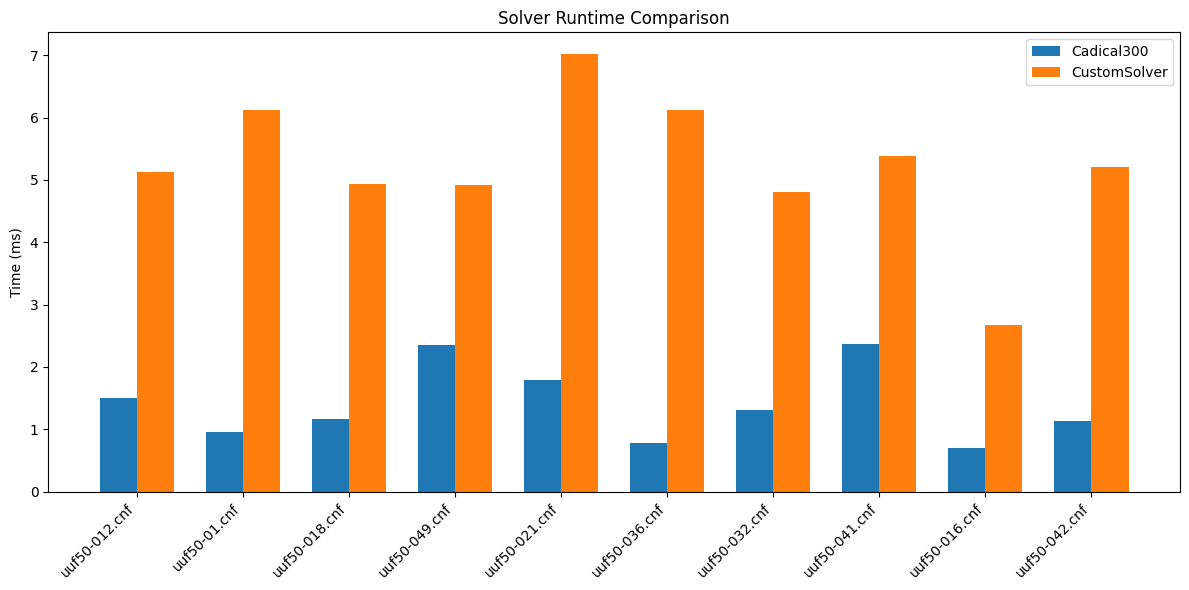

In [ ]:
def visualize_results(results_dict):
    """Grouped bar chart comparing Cadical300 vs CustomSolver time (ms) per instance."""
    instances = list(results_dict.keys())
    cadical_times = [results_dict[i].get("Cadical300", 0) for i in instances]
    custom_times = [results_dict[i].get("CustomSolver", 0) for i in instances]

    x = range(len(instances))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(instances) * 1.2), 6))
    ax.bar([i - width / 2 for i in x], cadical_times, width, label="Cadical300")
    ax.bar([i + width / 2 for i in x], custom_times, width, label="CustomSolver")

    ax.set_ylabel("Time (ms)")
    ax.set_title("Solver Runtime Comparison")
    ax.set_xticks(list(x))
    ax.set_xticklabels(instances, rotation=45, ha="right")
    ax.legend()
    fig.tight_layout()

    plt.savefig("solver_comparison.png", dpi=150)
    plt.show()

visualize_results(results)